### Megoldás
A notebookban egy Agentic RAG alapú megoldást implementáltam, amely egy adott kérdésre ad választ a kapott PDF alapján. Amennyiben a kérdés nem releváns a témához (mely döntést az LLM hozza meg), úgy nem ad az ágens érdemi választ. Ha azonban releváns, akkor a vektoradatbázisból a szöveg lényegi részeit kinyerjük a kérdés embeddingje alapján. A kérdést és a kontextust felhasználva állítja elő az LLM a válaszát. A válasz minőségét ellenőrzi ezután. Amennyiben az megfelelő, úgy az lesz a végső válasz, ellenkező esetben javítja azt. Ha egy maximum értéknél többször kell javítani a választ, akkor az ágens a váalszában jelzi, hogy nem tudta létrehozni megfelelő minőségben a választ.

A megoldás lokális GPU-t feltételez, az LLM-et az Ollama könytárral futtatja. A reprodukálhatóság érdekében az LLM temperature értéket 0-ra állítottam. A kód Google Colab notebook-ban lett tesztelve.

### Notebook felépítése:

1.   **Setup:** könyvtárak, dependenciák letöltése, Ollama indítása a lokális LLM-futtatáshoz.
2.   **Importálás:** könyvtárak importálása, paraméterek beállítása, modell betöltése.
3.   **Adatfeldolgozás:** PDF letöltése, chunkolása, vektoradatbázis elkészítése. A chunkokat egy nyílt forráskódú (open-source) embedding modellel alakítja vektorokká, majd a FAISS könyvtárral hoztam létre a vektoradatbázist.
4. **Agent és a gráf létrehozása:** definiáltam az egyes node-okat és az útvonalválasztáshoz szükséges kondíciós függvényeket, majd felépítettem a gráfot. Ezt vizuálisan is megjelenítettem.
5. **Tesztelés:** néhány egyszerű teszttel validáltam az ágens helyes működését. Egy releváns és egy nem releváns kérdést tettem fel, melyekre az ágens helyesen, az elvártnak megfelelően válaszolt.

### Tervezési döntések, alkalmazott architektúra:

*   A Qwen2.5-14B nagy nyelvi modellt alkalmaztam, amely használható egy 16GB-os GPU-n. Lokálisan futtattam, a reprodukálhatóság érdekében a temperature értéket 0-ra állítottam.
*   Vektoradatbázis és Embedding (FAISS + all-MiniLM-L6-v2): Ezek a nyílt forráskódú, erőforrás-hatékony megoldások, megfelelnek a minőségi, illetve skálázhatósági elvárásoknak.
*   LangGraph framework: Az elvárásokban rögzített keretrendszer.

### Bottleneck-ek:

*   Egy kérdés megválaszolása sok LLM futtatást is igényelhet, attól függően, hányszor kell újragenerálni a választ.
*   A jelenlegi, karakteralapú darabolást alkalmazó chunking stratégia elég statikus, megszakíthat összefüggő részeket.
* A válasz minőségének ellenőrzésének lépése (quality check) egyelőre nem elég robosztus a hallucinációval szemben.

### Tesztelés:

*   RAGAs: Hallucináció, válasz relevanciájának és kinyerés pontosságának mérése.
*   Node-ok tesztelése unit tesztekkel.
*   Egyes lépések, válaszok generálásának idejének mérése.

### Továbbfejlesztési lehetőségek:

*   Retrieval fejlesztése: kulcsszó alapú keresés vagy Reranking.
*   Karakteralapú chunking helyett a jelentés mentén (pl bekezdés alapján) szétválasztás.
* Structured Outputs használata a válasz string-jében megjelenő "igen" vagy "nem" szavak keresése helyett.
* Feladat komplexitása alapján szét lehetne osztani a feladatokat: a könnyebb task-okat egy kisebb modell végezné.
* A válasz újragenerálásakor (regenerate_answer) új kontextust is meg lehetne adni, hiszen lehet a rossz korábbi kontextus okozta a rossz választ. Ezt az új kontextust egy (LLM-mel) újrafogalmazott query-vel lehetne kinyerni.







#Setup

In [1]:
!pip install -qU langgraph langchain langchain-community langchain-huggingface faiss-cpu sentence-transformers pypdf langchain-ollama
!sudo apt-get update && sudo apt-get install zstd -y

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [2]:
import subprocess
import time
import os

!sudo apt install -y pciutils
!curl -fsSL https://ollama.com/install.sh | sh
env = os.environ.copy()
env["OLLAMA_LOG_LEVEL"] = "error"
with open(os.devnull, 'w') as fnull:
  subprocess.Popen(
      ["ollama", "serve"],
      env=env,
      stdout=fnull,
      stderr=fnull
  )

time.sleep(5) # várunk hogy biztos felálljon a szerver
!ollama pull qwen2.5:14b

print("Ollama letöltve és fut")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pciutils is already the newest version (1:3.7.0-6).
0 upgraded, 0 newly installed, 0 to remove and 88 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

Ollama letöltve és fut


# Könyvtárak importálása, paraméterek beállítása, modell betöltése

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_community.document_loaders import PyPDFLoader

In [4]:
CHUNK_SIZE = 500
CHUNK_OVERLAP = 100
TOP_K = 2  # a bemenet embeddingjéhez legközelebbi k chunk-ot adja vissza
TOPIC = "Transformer - Attention Is All You Need paper"
PDF_LINK = "https://arxiv.org/pdf/1706.03762"
MAX_REGENERATE_NUM = 1

In [5]:
llm = ChatOllama(model="qwen2.5:14b", temperature=0)

# PDF letöltése, chunk-olása, vektoradatbázis elkészítése

In [6]:
loader = PyPDFLoader(PDF_LINK)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
splits = text_splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(documents=splits, embedding=embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Agent és a gráf létrehozása

In [7]:
class AgentState(TypedDict):
  question: str
  relevant_parts: list[str] | None
  llm_answer: str | None
  retry_count: int
  is_relevant: bool | None
  quality_check_passed: bool
  answer: str | None

def check_relevance(state: AgentState):
  """Az LLM önállóan eldönti, hogy a kérdés releváns-e a témához."""
  print("- Relevancia vizsgálata.")
  question = state["question"]
  topic = TOPIC

  prompt = HumanMessage(
    "Te egy értékelő vagy, aki a megadott kérdés alapján eldönti, hogy az releváns-e a témakörhöz.\n"
    f"Kérdés: {question}\n"
    f"Témakör: {topic}\n"
    "Csak ennyit válaszolj: 'igen' vagy 'nem'."
  )
  messages = [prompt]
  result = llm.invoke(messages).content.lower()

  is_relevant = "igen" in result
  return {"is_relevant": is_relevant}

def retrieve(state: AgentState):
  """A függvény a kérdés embedding-je alapján választja ki a dokumentum releváns részeit."""
  print("- Dokumentum releváns részeinek lekérdezése.")
  docs = retriever.invoke(state["question"])
  return {"relevant_parts": [doc.page_content for doc in docs]}

def generate_answer(state: AgentState):
  """Az LLM legenerálja a végső választ a kontextus alapján"""
  print("- Válasz generálása LLM-mel.")
  question = state["question"]
  context = "\n".join(state["relevant_parts"])

  prompt = HumanMessage(
    ("Válaszold meg a kérdést magyarul a megadott kontextus alapján. Kizárólag a kontextus-ban megjelenő információt használd fel, és csak a kérdésre válaszolj.\n"
    f"Kérdés: {question}\n"
    f"Kontextus: {context}\n"
    "Válasz:")
  )
  messages = [prompt]
  response = llm.invoke(messages).content
  return {"llm_answer": response}

def quality_check(state: AgentState):
  """Ellenőrzi, hogy az LLM által generált válasz helyes-e és választ ad-e a kérdésre."""
  print("- LLM válaszának kiértékelése.")
  question = state["question"]
  answer = state["llm_answer"]
  prompt = HumanMessage(
      (f"Ellenőrizd a válasz minőségét. A válasznak nyelvtanilag helyesnek kell lennie, illetve a kérdésre kell válaszolnia. Csak az igazán súlyos hibákat figyeld."
      "Add meg, hogy ezen feltételek alapján megfelelő-e a válasz minősége. Ha van súlyos hiba, vagy a válasz teljesen független a kérdéstől, a válasz 'nem', ellenkező esetben 'igen'. "
      "Csak ennyit válaszolj: 'igen' vagy 'nem'.\n"
      f"Kérdés: {question}\n"
      f"Válasz: {answer}\n"
      )
  )
  messages = [prompt]
  response = llm.invoke(messages).content.lower()

  quality_check_passed = "igen" in response
  return {"quality_check_passed": quality_check_passed}

def regenerate_answer(state: AgentState):
  """Az LLM módosítja, helyesbíti a korábbi választ."""
  print("- Válasz újragenerálása LLM-mel.")
  question = state["question"]
  context = "\n".join(state["relevant_parts"])
  previous_answer = state["llm_answer"]

  prompt = HumanMessage(
    (f"A korábbi választ módosítsd, javítsd úgy, hogy helyes legyen nyelvtanilag és válaszoljon a kérdésre. Kizárólag a kontextus-ban megjelenő információt használd fel, és csak a kérdésre válaszolj.\n"
    f"Kérdés: {question}\n"
    f"Kontextus: {context}\n",
    f"Korábbi válasz: {previous_answer}\n"
    "Javított válasz:")
  )
  messages = [prompt]
  response = llm.invoke(messages).content
  new_retry_count = state["retry_count"] + 1
  return {"llm_answer": response, "retry_count": new_retry_count}

def answer(state: AgentState):
  """
    Válasz létrehozása. Amennyiben nem volt releváns a témához úgy jelzi ezt.
    Ha Nem volt megfelelő a generált válasz minősége, úgy nem adunk érdemi választ.
    Ha releváns a kérdés, és jó minőségű az LLM válasza, akkor az lesz az ágens válasz.
  """
  print("- Végső válasz létrehozása.")
  if state["is_relevant"]:
    if state["quality_check_passed"]:
      answer = state["llm_answer"]
    else:
      answer = "Sajnos nem tudtam megfelelő minőségben megválaszolni a kérdést."
  else:
    answer = f"A kérdés nem kapcsolódik a - {TOPIC} - témakörhöz."
  return {"answer": answer}


def route_after_relevance_check(state: AgentState):
  if state.get("is_relevant"):
      return "retrieve"
  else:
      return "answer"

def route_after_quality_check(state: AgentState):
  if state.get("quality_check_passed") or state.get("retry_count", 0) >= MAX_REGENERATE_NUM:
      return "answer"
  else:
      return "regenerate_answer"


In [8]:
graph = StateGraph(AgentState)

graph.add_node("check_relevance", check_relevance)
graph.add_node("retrieve", retrieve)
graph.add_node("generate_answer", generate_answer)
graph.add_node("quality_check", quality_check)
graph.add_node("regenerate_answer", regenerate_answer)
graph.add_node("answer", answer)

graph.add_edge(START, "check_relevance")
graph.add_conditional_edges("check_relevance", route_after_relevance_check, {
    "retrieve": "retrieve",
    "answer": "answer"
})
graph.add_edge("retrieve", "generate_answer")
graph.add_edge("generate_answer", "quality_check")
graph.add_conditional_edges("quality_check", route_after_quality_check, {
    "regenerate_answer": "regenerate_answer",
    "answer": "answer"
})
graph.add_edge("regenerate_answer", "quality_check")
graph.add_edge("answer", END)

compiled_graph = graph.compile()

In [9]:
initial_state = {
  "relevant_parts": None,
  "llm_answer": None,
  "retry_count": 0,
  "is_relevant": None,
  "quality_check_passed": False,
  "answer": None,
  }

# Tesztelés

In [14]:
Question1 = "Mi az az attention?"
Question2 = "Mi az a transformer, hogyan működik?"
Question3 = "Hogy süssek palacsintát?"

print("1. TESZT: Releváns kérdés")
state1 = {"question": Question1, **initial_state}
result_1 = compiled_graph.invoke(state1)
print(f"\nVÉGSŐ VÁLASZ: {result_1["answer"]}\n")

print("2. TESZT: Releváns kérdés")
state2 = {"question": Question2, **initial_state}
result_2 = compiled_graph.invoke(state2)
print(f"\nVÉGSŐ VÁLASZ: {result_2["answer"]}\n")

print("3. TESZT: Irreleváns kérdés")
state3 = {"question": Question3, **initial_state}
result_3 = compiled_graph.invoke(state3)
print(f"\nVÉGSŐ VÁLASZ: {result_3["answer"]}\n")

1. TESZT: Releváns kérdés
- Relevancia vizsgálata.
- Dokumentum releváns részeinek lekérdezése.
- Válasz generálása LLM-mel.
- LLM válaszának kiértékelése.
- Végső válasz létrehozása.

VÉGSŐ VÁLASZ: A kontextusban szereplő hivatkozások alapján a "attention" (figyelés) egy mechanizmus, amely a neurális hálózatokban használatos, különösen a nyelvészeti alkalmazásokban, például a neurális mátrix fordításban. Az attention-módszerek lehetővé teszik a modelleknek a releváns információk kiválasztását és fókuszolását a jelenlegi feladat szempontjából, így javítva a rendszerek teljesítményének és hatékonyságának. Az attention mechanizmus segítségével a modellek jobban képesek végighaladni a releváns részletek között, amikor például egy mondatot vagy egy szöveget feldolgoznak vagy fordítanak.

2. TESZT: Releváns kérdés
- Relevancia vizsgálata.
- Dokumentum releváns részeinek lekérdezése.
- Válasz generálása LLM-mel.
- LLM válaszának kiértékelése.
- Válasz újragenerálása LLM-mel.
- LLM válaszának

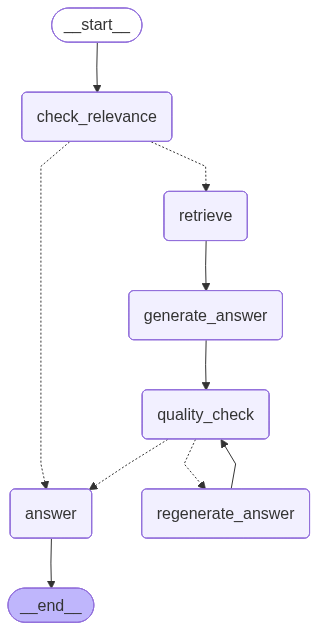

In [11]:
from IPython.display import Image, display

graph_png = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_png))